# Week 10 Tutorial - PyTorch Fundamentals

**How to use this notebook:**
Read one section of `study-guide.md`, then do that section here before moving on.

Each section has:
- A worked example (pre-written - just run it)
- A **DO IT YOURSELF** cell with different data

---

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer, load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print('PyTorch version:', torch.__version__)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)

PyTorch version: 2.8.0+cu126
Device: cuda


---
## Section 1 - Tensors
### EXAMPLE

In [2]:
# EXAMPLE: tensor creation and operations

# creating tensors
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.zeros(3)
c = torch.ones(2, 3)
d = torch.randn(3, 4)   # random normal

print('a:', a)
print('shape:', a.shape)
print('dtype:', a.dtype)
print()

# operations
x = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
y = torch.tensor([[5.0, 6.0], [7.0, 8.0]])

print('x + y:', x + y)
print('x * y (element-wise):', x * y)
print('x @ y (matrix multiply):', x @ y)
print('x.T (transpose):', x.T)
print('x.mean():', x.mean())
print()

# numpy conversion
arr = np.array([1.0, 2.0, 3.0])
tensor_from_np = torch.from_numpy(arr)
back_to_np = tensor_from_np.numpy()
print('numpy → tensor:', tensor_from_np)
print('tensor → numpy:', back_to_np)

a: tensor([1., 2., 3.])
shape: torch.Size([3])
dtype: torch.float32

x + y: tensor([[ 6.,  8.],
        [10., 12.]])
x * y (element-wise): tensor([[ 5., 12.],
        [21., 32.]])
x @ y (matrix multiply): tensor([[19., 22.],
        [43., 50.]])
x.T (transpose): tensor([[1., 3.],
        [2., 4.]])
x.mean(): tensor(2.5000)

numpy → tensor: tensor([1., 2., 3.], dtype=torch.float64)
tensor → numpy: [1. 2. 3.]


### DO IT YOURSELF - Section 1

1. Create a tensor of shape (4, 3) filled with random normal values
2. Create a tensor of shape (3, 2) filled with ones
3. Matrix multiply them and print the result shape
4. Compute the mean along dimension 0 (across rows) and print the shape
5. Comment: what shape do you expect before running?

In [5]:
# DO IT YOURSELF - Section 1
# YOUR CODE HERE

a = torch.randn(4, 3)
b = torch.ones(3, 2)

c = a @ b
print('a @ b (matrix multiply):', c)
print('c shape: ', c.shape)

mean = c.mean(dim=0)
print('c.mean(dim=0): ', mean) 
print('c.mean(dim=0) shape: ', mean.shape) # should be (2, )

a @ b (matrix multiply): tensor([[ 0.8393,  0.8393],
        [ 1.9553,  1.9553],
        [ 0.5800,  0.5800],
        [-1.4345, -1.4345]])
c shape:  torch.Size([4, 2])
c.mean(dim=0):  tensor([0.4850, 0.4850])
c.mean(dim=0) shape:  torch.Size([2])


---
## Section 2 - Autograd
### EXAMPLE

In [6]:
# EXAMPLE: autograd computing gradients automatically
# Compare to week 9 where we computed dL/dW manually

# simple scalar example: y = x^2, dy/dx = 2x
x = torch.tensor(3.0, requires_grad=True)
y = x ** 2
y.backward()
print('x:', x.item())
print('y = x^2:', y.item())
print('dy/dx (should be 2*3=6):', x.grad.item())
print()

# more complex: z = 3x^2 + 2x + 1, dz/dx = 6x + 2
x = torch.tensor(2.0, requires_grad=True)
z = 3 * x**2 + 2 * x + 1
z.backward()
print('x:', x.item())
print('z = 3x^2 + 2x + 1:', z.item())
print('dz/dx (should be 6*2+2=14):', x.grad.item())
print()

# matrix example: same as week 9 W update but autograd does it
W = torch.randn(3, 4, requires_grad=True)
X = torch.randn(5, 3)
y = torch.randn(5, 4)

pred = X @ W
loss = ((pred - y) ** 2).mean()
loss.backward()

print('W.grad shape:', W.grad.shape)  # same shape as W
print('Loss:', loss.item())

x: 3.0
y = x^2: 9.0
dy/dx (should be 2*3=6): 6.0

x: 2.0
z = 3x^2 + 2x + 1: 17.0
dz/dx (should be 6*2+2=14): 14.0

W.grad shape: torch.Size([3, 4])
Loss: 3.015045642852783


### DO IT YOURSELF - Section 2

1. Create `x = torch.tensor(4.0, requires_grad=True)`
2. Compute `y = x^3 - 2*x^2 + x`
3. Call `.backward()` and print the gradient
4. Manually verify: the derivative of `x^3 - 2x^2 + x` is `3x^2 - 4x + 1` — plug in x=4 and check
5. Comment: what would happen if you forgot `requires_grad=True`?

In [9]:
# DO IT YOURSELF - Section 2
# YOUR CODE HERE
x = torch.tensor(4.0, requires_grad=True)
y = x**3 - (2 * (x**2)) + x
y.backward()

y_grad = (3 * (4 ** 2)) - (4 * 4) + 1

print(f'3x^2 - 4x + 1 manual: {y_grad}')
print(f'3x^2 - 4x + 1 tensor: {x.grad.item()}')

# if you forget requires_grad than it would not track your operation and therefore will not calculate gradient 

3x^2 - 4x + 1 manual: 33
3x^2 - 4x + 1 tensot: 33.0


---
## Section 3 - nn.Module
### EXAMPLE

In [10]:
# EXAMPLE: same 2-layer network from week 9, now in PyTorch
# week 9: W1 = np.random.randn(3,4)*0.1, manual z1=X@W1+b1, a1=relu(z1) ...
# week 10: nn.Linear handles all of that

class SimpleNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        x = self.fc1(x)     # z1 = x @ W1 + b1
        x = self.relu(x)    # a1 = ReLU(z1)
        x = self.fc2(x)     # z2 = a1 @ W2 + b2
        return x             # raw logit (sigmoid applied in loss)

model = SimpleNet(input_size=3, hidden_size=4, output_size=1)
print(model)
print()

# inspect weights — PyTorch stores them automatically
print('fc1 weight shape:', model.fc1.weight.shape)   # (4, 3) — note: transposed vs week 9
print('fc1 bias shape:  ', model.fc1.bias.shape)     # (4,)
print('fc2 weight shape:', model.fc2.weight.shape)   # (1, 4)
print()

# same tiny dataset from week 9
X = torch.tensor([[0.5, 1.2, -0.3],
                   [1.1, -0.5, 0.8],
                   [-0.3, 0.7, 1.5],
                   [0.9, 0.2, -0.7],
                   [-0.5, 1.0, 0.3]], dtype=torch.float32)

# forward pass — same as week 9 but no manual matrix math
with torch.no_grad():
    out = model(X)
    print('Output shape:', out.shape)
    print('Raw logits:', out.flatten().round(decimals=4))
    print('Probabilities:', torch.sigmoid(out).flatten().round(decimals=4))

SimpleNet(
  (fc1): Linear(in_features=3, out_features=4, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=4, out_features=1, bias=True)
)

fc1 weight shape: torch.Size([4, 3])
fc1 bias shape:   torch.Size([4])
fc2 weight shape: torch.Size([1, 4])

Output shape: torch.Size([5, 1])
Raw logits: tensor([ 0.3399,  0.0122, -0.0559,  0.3494,  0.2361])
Probabilities: tensor([0.5842, 0.5031, 0.4860, 0.5865, 0.5588])


In [11]:
# EXAMPLE: same network using nn.Sequential (shorthand for simple linear stacks)

model_seq = nn.Sequential(
    nn.Linear(3, 4),
    nn.ReLU(),
    nn.Linear(4, 1)
)

print(model_seq)
print()

# count total parameters
total = sum(p.numel() for p in model_seq.parameters())
print(f'Total parameters: {total}')
# W1: 3*4=12, b1: 4, W2: 4*1=4, b2: 1 → total: 21

Sequential(
  (0): Linear(in_features=3, out_features=4, bias=True)
  (1): ReLU()
  (2): Linear(in_features=4, out_features=1, bias=True)
)

Total parameters: 21


### DO IT YOURSELF - Section 3

Dataset: wine (3 classes, 13 features)

1. Define a network using `nn.Module` with architecture: 13 → 32 → 16 → 3
2. Use ReLU for hidden layers
3. Print the model and count total parameters
4. Run a forward pass on a single random input of shape (1, 13) and print the output
5. Comment: why does `forward` not apply any activation on the final layer?

In [45]:
# DO IT YOURSELF - Section 3
# YOUR CODE HERE
# DO IT YOURSELF - Section 3
# YOUR CODE HERE
class WineNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(13, 32)
        self.fc2 = nn.Linear(32, 16)
        self.fc3 = nn.Linear(16, 3)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        return x  # raw logits — activation applied in loss or manually after

model = WineNet()
print(model)

total = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total}')

X_rand = torch.randn(1, 13)
with torch.no_grad():
    out = model(X_rand)
    print('Output shape:', out.shape)
    print('Raw logits:', out)

# forward returns raw logits because loss functions like CrossEntropyLoss
# apply softmax internally. Adding it here would apply it twice.
# For predicting class we use argmax on raw logits directly.

WineNet(
  (fc1): Linear(in_features=13, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=16, bias=True)
  (fc3): Linear(in_features=16, out_features=3, bias=True)
  (relu): ReLU()
)
Total parameters: 1027
Output shape: torch.Size([1, 3])
Raw logits: tensor([[-0.1655, -0.0848,  0.1215]])


---
## Section 4 - Training Loop
### EXAMPLE

In [ ]:
# EXAMPLE: full training loop on the week 9 toy dataset
# Same network and data as week 9 Section 4 — but now autograd replaces manual backprop

torch.manual_seed(42)

X = torch.tensor([[0.5, 1.2, -0.3],
                   [1.1, -0.5, 0.8],
                   [-0.3, 0.7, 1.5],
                   [0.9, 0.2, -0.7],
                   [-0.5, 1.0, 0.3]], dtype=torch.float32)
y = torch.tensor([[1.], [0.], [1.], [0.], [1.]])

model = nn.Sequential(
    nn.Linear(3, 4),
    nn.ReLU(),
    nn.Linear(4, 1)
)

# BCEWithLogitsLoss = sigmoid + binary cross entropy (more numerically stable)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.1)

loss_history = []

for epoch in range(200):
    model.train()
    
    optimizer.zero_grad()          # clear gradients
    y_pred = model(X)              # forward pass
    loss = criterion(y_pred, y)    # compute loss
    loss.backward()                # autograd: compute all gradients
    optimizer.step()               # update weights
    
    loss_history.append(loss.item())

plt.figure(figsize=(8, 4))
plt.plot(loss_history, 'steelblue')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training loss — PyTorch (same network as week 9)')
plt.grid(alpha=0.3)
plt.show()

model.eval()
with torch.no_grad():
    logits = model(X)
    probs  = torch.sigmoid(logits)
    preds  = (probs > 0.5).int().flatten()

print(f'Initial loss: {loss_history[0]:.4f}')
print(f'Final loss:   {loss_history[-1]:.4f}')
print(f'Predictions:  {preds.tolist()}')
print(f'True labels:  {[1,0,1,0,1]}')

### DO IT YOURSELF - Section 4

Dataset: wine (multiclass — 3 classes)

1. Load wine data, scale it, convert to tensors
2. Define a network: 13 → 32 → 16 → 3
3. Use `nn.CrossEntropyLoss()` (multiclass) and `optim.Adam` with lr=0.01
4. Train for 300 epochs, track loss
5. Plot loss curve
6. Print accuracy on test set

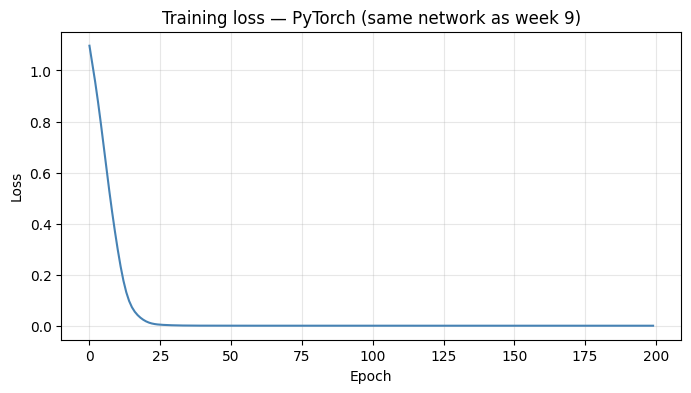

Test accuracy: 0.9722


In [ ]:
# DO IT YOURSELF - Section 4
# YOUR CODE HERE
torch.manual_seed(42)

wine = load_wine()
X_w_np, y_w_np = wine.data, wine.target

X_w_train_np, X_w_test_np, y_w_train_np, y_w_test_np = train_test_split(
    X_w_np, y_w_np, test_size=0.2, random_state=42, stratify=y_w_np
)

scaler = StandardScaler()
X_w_train_sc = scaler.fit_transform(X_w_train_np)
X_w_test_sc  = scaler.transform(X_w_test_np)

X_w_train = torch.tensor(X_w_train_sc, dtype=torch.float32)
X_w_test  = torch.tensor(X_w_test_sc,  dtype=torch.float32)
y_w_train = torch.tensor(y_w_train_np, dtype=torch.long)
y_w_test  = torch.tensor(y_w_test_np,  dtype=torch.long)

model = nn.Sequential(
    nn.Linear(13, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 3),
)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

loss_history = []

for epoch in range(200):
    model.train()
    
    optimizer.zero_grad()          # clear gradients
    y_w_pred = model(X_w_train)              # forward pass
    loss = criterion(y_w_pred, y_w_train)    # compute loss
    loss.backward()                # autograd: compute all gradients
    optimizer.step()               # update weights
    
    loss_history.append(loss.item())

plt.figure(figsize=(8, 4))
plt.plot(loss_history, 'steelblue')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training loss — PyTorch (same network as week 9)')
plt.grid(alpha=0.3)
plt.show()

model.eval()
with torch.no_grad():
    logits = model(X_w_test)
    preds = torch.argmax(logits, dim=1)
    accuracy = (preds == y_w_test).float().mean()
    print(f'Test accuracy: {accuracy.item():.4f}')

---
## Section 5 - train() vs eval() and torch.no_grad()
### EXAMPLE

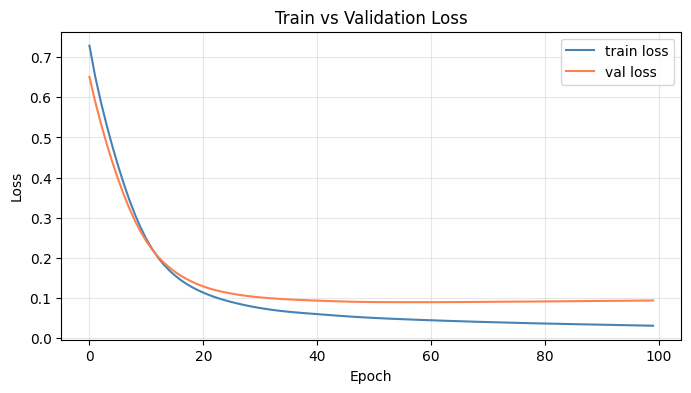

              precision    recall  f1-score   support

   malignant       0.91      0.98      0.94        42
      benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



In [34]:
# EXAMPLE: proper train/eval pattern on breast cancer

torch.manual_seed(42)

# load and prep data
cancer = load_breast_cancer()
X_np, y_np = cancer.data, cancer.target

X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X_np, y_np, test_size=0.2, random_state=42, stratify=y_np
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_np)
X_test_sc  = scaler.transform(X_test_np)

X_train = torch.tensor(X_train_sc, dtype=torch.float32)
X_test  = torch.tensor(X_test_sc,  dtype=torch.float32)
y_train = torch.tensor(y_train_np, dtype=torch.float32).unsqueeze(1)
y_test  = torch.tensor(y_test_np,  dtype=torch.float32).unsqueeze(1)

model = nn.Sequential(
    nn.Linear(30, 16),
    nn.ReLU(),
    nn.Linear(16, 1)
)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

train_losses = []
val_losses   = []

for epoch in range(100):
    # --- training ---
    model.train()
    optimizer.zero_grad()
    pred_train = model(X_train)
    loss_train = criterion(pred_train, y_train)
    loss_train.backward()
    optimizer.step()
    train_losses.append(loss_train.item())
    
    # --- evaluation ---
    model.eval()
    with torch.no_grad():
        pred_val  = model(X_test)
        loss_val  = criterion(pred_val, y_test)
        val_losses.append(loss_val.item())

plt.figure(figsize=(8, 4))
plt.plot(train_losses, 'steelblue', label='train loss')
plt.plot(val_losses,   'coral',     label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train vs Validation Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

model.eval()
with torch.no_grad():
    preds = (torch.sigmoid(model(X_test)) > 0.5).int().flatten().numpy()

print(classification_report(y_test_np, preds, target_names=cancer.target_names))

### DO IT YOURSELF - Section 5

Dataset: wine

1. Train the wine network from Section 4 but this time track both train loss AND val loss each epoch
2. Plot both on the same chart
3. Comment: is the model overfitting? How can you tell from the chart?

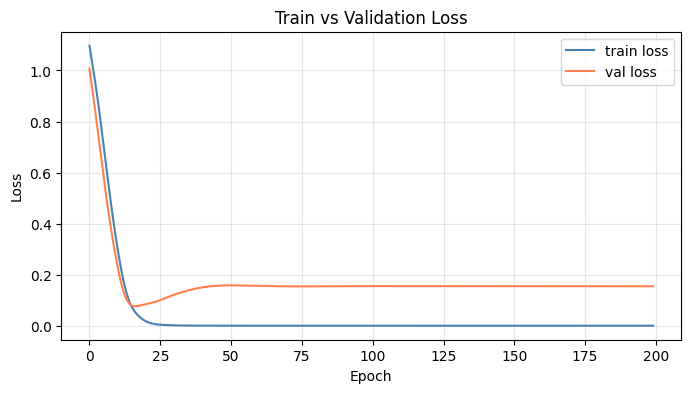

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



In [36]:
# DO IT YOURSELF - Section 5
# YOUR CODE HERE
# DO IT YOURSELF - Section 4
# YOUR CODE HERE
torch.manual_seed(42)

wine = load_wine()
X_w_np, y_w_np = wine.data, wine.target

X_w_train_np, X_w_test_np, y_w_train_np, y_w_test_np = train_test_split(
    X_w_np, y_w_np, test_size=0.2, random_state=42, stratify=y_w_np
)

scaler = StandardScaler()
X_w_train_sc = scaler.fit_transform(X_w_train_np)
X_w_test_sc  = scaler.transform(X_w_test_np)

X_w_train = torch.tensor(X_w_train_sc, dtype=torch.float32)
X_w_test  = torch.tensor(X_w_test_sc,  dtype=torch.float32)
y_w_train = torch.tensor(y_w_train_np, dtype=torch.long)
y_w_test  = torch.tensor(y_w_test_np,  dtype=torch.long)

model = nn.Sequential(
    nn.Linear(13, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 3),
)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

train_losses = []
val_losses   = []

for epoch in range(200):
    model.train()
    
    optimizer.zero_grad()          # clear gradients
    y_w_pred = model(X_w_train)              # forward pass
    loss = criterion(y_w_pred, y_w_train)    # compute loss
    loss.backward()                # autograd: compute all gradients
    optimizer.step()               # update weights
    
    train_losses.append(loss.item())

    # --- evaluation ---
    model.eval()
    with torch.no_grad():
        y_w_pred_val  = model(X_w_test)
        loss_val  = criterion(y_w_pred_val, y_w_test)
        val_losses.append(loss_val.item())

plt.figure(figsize=(8, 4))
plt.plot(train_losses, 'steelblue', label='train loss')
plt.plot(val_losses,   'coral',     label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train vs Validation Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

model.eval()
with torch.no_grad():
    logits = model(X_w_test)
    preds = torch.argmax(logits, dim=1).numpy()  # multiclass → argmax not sigmoid

print(classification_report(y_w_test_np, preds, target_names=wine.target_names))

# The difference in gap shows that its overfitting

---
## Section 6 - DataLoader
### EXAMPLE

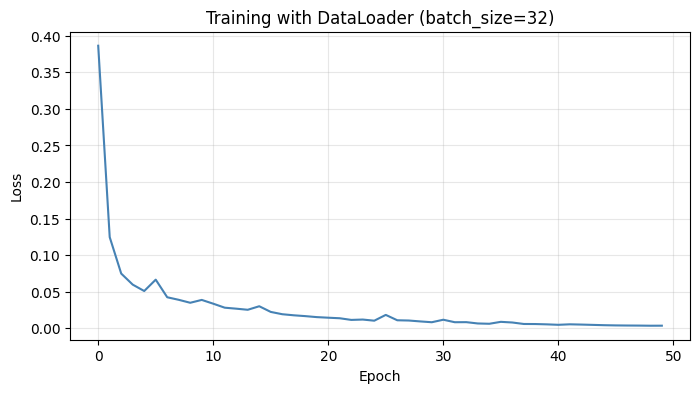

Batches per epoch: 15
Samples: 455, batch_size: 32 → 15 batches


In [37]:
# EXAMPLE: training with mini-batches using DataLoader
# Same breast cancer data, but now batched

torch.manual_seed(42)

# wrap tensors in Dataset and DataLoader
train_dataset = TensorDataset(X_train, y_train)
train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=True)

model = nn.Sequential(
    nn.Linear(30, 16),
    nn.ReLU(),
    nn.Linear(16, 1)
)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

epoch_losses = []

for epoch in range(50):
    model.train()
    batch_losses = []
    
    for X_batch, y_batch in train_loader:   # iterate over batches
        optimizer.zero_grad()
        pred  = model(X_batch)
        loss  = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    
    epoch_losses.append(np.mean(batch_losses))

plt.figure(figsize=(8, 4))
plt.plot(epoch_losses, 'steelblue')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training with DataLoader (batch_size=32)')
plt.grid(alpha=0.3)
plt.show()

print(f'Batches per epoch: {len(train_loader)}')
print(f'Samples: {len(train_dataset)}, batch_size: 32 → {len(train_loader)} batches')

### DO IT YOURSELF - Section 6

Dataset: wine

1. Wrap wine train data in a TensorDataset and DataLoader with batch_size=16
2. Train the 13→32→16→3 network for 100 epochs using the DataLoader
3. Plot the epoch loss curve
4. Comment: wine has 142 training samples — how many batches per epoch with batch_size=16?

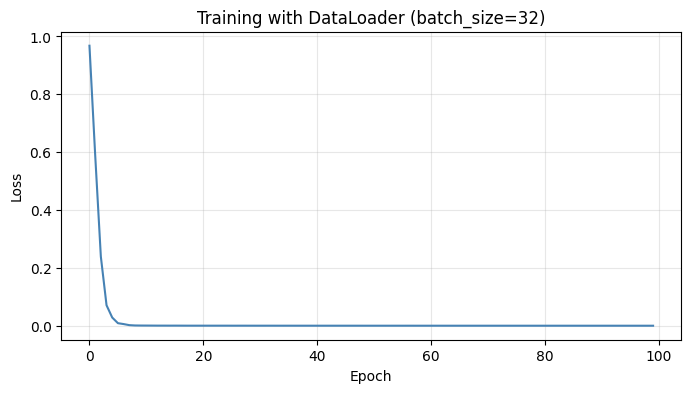

Batches per epoch: 5
Samples: 142, batch_size: 32 → 5 batches


In [ ]:
# DO IT YOURSELF - Section 6
# YOUR CODE HERE
torch.manual_seed(42)

train_dataset = TensorDataset(X_w_train, y_w_train)
train_loader  = DataLoader(train_dataset, batch_size=16, shuffle=True)


model = nn.Sequential(
    nn.Linear(13, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 3),
)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

epoch_losses = []

for epoch in range(100):
    model.train()
    batch_losses = []

    for X_batch, y_batch in train_loader:
    
        optimizer.zero_grad()          # clear gradients
        y_w_pred = model(X_batch)              # forward pass
        loss = criterion(y_w_pred, y_batch)    # compute loss
        loss.backward()                # autograd: compute all gradients
        optimizer.step()               # update weights
        batch_losses.append(loss.item())
    
    epoch_losses.append(np.mean(batch_losses))

plt.figure(figsize=(8, 4))
plt.plot(epoch_losses, 'steelblue')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training with DataLoader (batch_size=32)')
plt.grid(alpha=0.3)
plt.show()

print(f'Batches per epoch: {len(train_loader)}')
print(f'Samples: {len(train_dataset)}, batch_size: 32 → {len(train_loader)} batches')

#  142 samples / 16 = 8.875 → 9 batches

---
## CAPSTONE

1. Load the breast cancer dataset, scale it, convert to tensors
2. Build a PyTorch model — choose your own architecture (justify it)
3. Use Adam optimizer and BCEWithLogitsLoss
4. Train with a DataLoader (batch_size=32)
5. Track and plot train + val loss each epoch
6. Evaluate on test set: print classification report and confusion matrix
7. Compare test accuracy to week 9's sklearn MLPClassifier result
8. Written answer: what does PyTorch give you that sklearn does not? When would you use each?

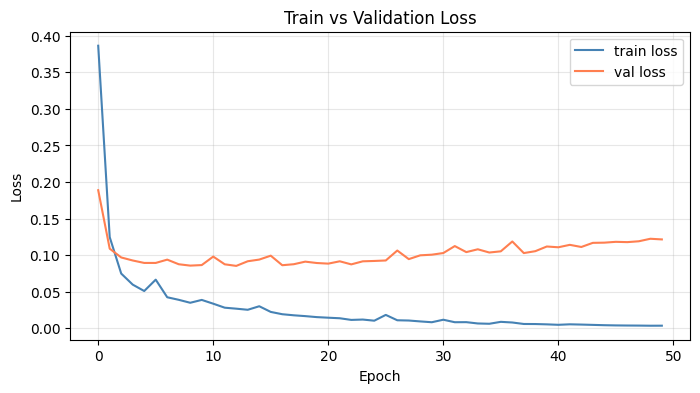

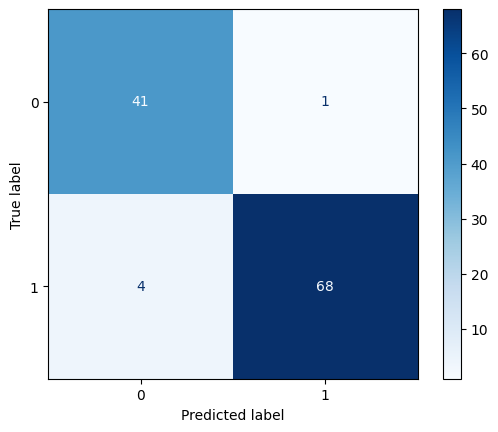

              precision    recall  f1-score   support

   malignant       0.91      0.98      0.94        42
      benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



In [44]:
torch.manual_seed(42)

cancer = load_breast_cancer()
X_np, y_np = cancer.data, cancer.target

X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X_np, y_np, test_size=0.2, random_state=42, stratify=y_np
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_np)
X_test_sc  = scaler.transform(X_test_np)

X_train = torch.tensor(X_train_sc, dtype=torch.float32)
X_test  = torch.tensor(X_test_sc,  dtype=torch.float32)
y_train = torch.tensor(y_train_np, dtype=torch.float32).unsqueeze(1)
y_test  = torch.tensor(y_test_np,  dtype=torch.float32).unsqueeze(1)

train_dataset = TensorDataset(X_train, y_train)
train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=True)

model = nn.Sequential(
    nn.Linear(30, 16),
    nn.ReLU(),
    nn.Linear(16, 1)
)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

epoch_losses = []
val_losses   = []

for epoch in range(50):
    model.train()
    batch_losses = []
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    epoch_losses.append(np.mean(batch_losses))

    model.eval()
    with torch.no_grad():
        val_pred = model(X_test)
        val_loss = criterion(val_pred, y_test)
        val_losses.append(val_loss.item())

plt.figure(figsize=(8, 4))
plt.plot(epoch_losses, 'steelblue', label='train loss')
plt.plot(val_losses,   'coral',     label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train vs Validation Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

model.eval()
with torch.no_grad():
    preds = (torch.sigmoid(model(X_test)) > 0.5).int().flatten().numpy()

cm = confusion_matrix(y_test_np, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.show()

print(classification_report(y_test_np, preds, target_names=cancer.target_names))

# sklearn for quick validation for choosing model or simple data
# for fine tuning and customizing each steps use torch